Import libraries

In [1]:
pip install xgboost

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
from skopt import BayesSearchCV
from skopt.plots import plot_convergence, plot_objective, plot_evaluations

Import dataset

In [3]:
url = "2023_Data_BiomassGasification_NED.xlsx"
Data = pd.read_excel(url, sheet_name='Normalized Data')
Data.head()

,feed_particle_size,feed_LHV,C,H,N,S,O,feed_ash,feed_moisture,feed_VM,...,other_bed,alumina,Y-alumina,calcium oxide,dolomite,olivine,silica,sand,lab,pilot
0,0.0681,0.236607,0.420376,0.458096,0.127396,0.042204,0.604911,0.467066,0.125441,0.196338,...,0,0,0,0,0,1,0,0,0,1
1,0.0681,0.236607,0.420376,0.458096,0.127396,0.042204,0.604911,0.467066,0.125441,0.196338,...,0,0,0,0,0,1,0,0,0,1
2,0.0681,0.236607,0.420376,0.458096,0.127396,0.042204,0.604911,0.467066,0.125441,0.196338,...,0,0,0,0,0,1,0,0,0,1
3,0.0681,0.236607,0.420376,0.458096,0.127396,0.042204,0.604911,0.467066,0.125441,0.196338,...,0,0,0,0,0,1,0,0,0,1
4,0.0681,0.236607,0.420376,0.458096,0.127396,0.042204,0.604911,0.467066,0.125441,0.196338,...,0,0,0,0,0,1,0,0,0,1


Data splitting (70% training, 30% testing)

In [4]:
X = Data.loc[:, ~Data.columns.isin(['N2', 'H2', 'CO', 'CO2', 'CH4', 'C2Hn', 'gas_LHV', 'gas_tar', 'gas_yield', 'char_yield', 'CGE', 'CCE', 'feed_cellulose', 'feed_hemicellulose', 'feed_lignin', 'residence_time', '111.46', '205', 'atmospheric', 'slightly below atmospheric', 'feed_LHV', 'feed_VM', 'feed_FC', 'other_feed_types', 'other_feed_shape', 'batch', 'other_gas', 'other_bed', 'dolomite'])]
Y = Data.loc[:, Data.columns.isin(['H2', 'CO2', 'gas_tar'])]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.7, random_state=42)

Hyperparameter tuning using Bayesian optimization

In [5]:
#Define model
GBR = GradientBoostingRegressor()
XGB = XGBRegressor(objective='reg:squarederror')
ADA = AdaBoostRegressor(estimator=DecisionTreeRegressor())

def hyperparameter_tuning(model_name, X, Y, output):
  if model_name == GBR:
    #Define search spaces of every hyperparameter tuned in GBR
    search_spaces = {
        'n_estimators': (50, 500),
        'learning_rate': (1e-3, 1.0, 'log-uniform'),
        'max_depth': (1, 20),
        'min_samples_split': (2, 20),
        'min_samples_leaf': (1, 20),
        'subsample': (0.1, 1.0, 'uniform'),
        'max_features': (0.1, 1.0, 'uniform')
    }

  elif model_name == XGB:
    search_spaces = {
        'n_estimators': (50, 1000),
        'learning_rate': (0.01, 1.0, 'log-uniform'),
        'max_depth': (1, 10),
        'min_child_weight': (1, 10),
        'subsample': (0.5, 1.0, 'uniform'),
        'colsample_bytree': (0.5, 1.0, 'uniform'),
        'gamma': (0, 5),
        'reg_alpha': (1e-5, 1.0, 'log-uniform'),
        'reg_lambda': (1e-5, 1.0, 'log-uniform')
    }
  elif model_name == ADA:
    search_spaces = {
        'n_estimators': (50, 1000),
        'learning_rate': (0.01, 1.0, 'log-uniform'),
        'loss': ['linear', 'square', 'exponential']
    }


  #Create optimize
  opt = BayesSearchCV(
      estimator=model_name,
      search_spaces=search_spaces,
      cv=5,
      n_iter=32,
      scoring='r2',
      n_jobs=-1,
      random_state=42
  )

  #Fit traning data with optimizer
  opt.fit(X, Y[output])

  #Show optimization results
  print('Hyperparameter tuning of ', model_name,' model')
  print('Best parameters: ', opt.best_params_)
  print('Best score: ', opt.best_score_)
  print('--------------------------------------')

  return opt

In [6]:
#Get hyperparameters for GBR model
GBR_H2 = hyperparameter_tuning(GBR, X_train, Y_train, output='H2')

Hyperparameter tuning of  GradientBoostingRegressor()  model
Best parameters:  OrderedDict([('learning_rate', 0.10696599182433328), ('max_depth', 20), ('max_features', 0.1), ('min_samples_leaf', 1), ('min_samples_split', 13), ('n_estimators', 135), ('subsample', 0.6916694645849748)])
Best score:  0.9276315984467338
--------------------------------------


In [7]:
GBR_CO2 = hyperparameter_tuning(GBR, X_train, Y_train, output='CO2')

Hyperparameter tuning of  GradientBoostingRegressor()  model
Best parameters:  OrderedDict([('learning_rate', 0.16562314152719596), ('max_depth', 20), ('max_features', 0.1645312455555058), ('min_samples_leaf', 1), ('min_samples_split', 11), ('n_estimators', 76), ('subsample', 0.9954719765105854)])
Best score:  0.8503417600755834
--------------------------------------


In [26]:
GBR_Tar = hyperparameter_tuning(GBR, X_train, Y_train, output='gas_tar')

Hyperparameter tuning of  GradientBoostingRegressor()  model
Best parameters:  OrderedDict([('learning_rate', 0.12453022056969862), ('max_depth', 11), ('max_features', 0.3863642912083358), ('min_samples_leaf', 11), ('min_samples_split', 19), ('n_estimators', 500), ('subsample', 0.7540480576687604)])
Best score:  0.7656458530970253
--------------------------------------


In [9]:
#Get hyperparameters for XGB model
XGB_H2 = hyperparameter_tuning(XGB, X_train, Y_train, output='H2')

Hyperparameter tuning of  XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)  model
Best parameters:  OrderedDict([('colsample_bytree', 1.0), ('gamma', 0), ('learning_rate', 0.039725645406405406), ('max_depth', 7), ('min_child_weight', 1), ('n_estimators', 1000), ('reg_alpha', 1e-05), ('reg_lambda', 1.0

In [10]:
XGB_CO2 = hyperparameter_tuning(XGB, X_train, Y_train, output='CO2')

Hyperparameter tuning of  XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)  model
Best parameters:  OrderedDict([('colsample_bytree', 0.5), ('gamma', 0), ('learning_rate', 0.01), ('max_depth', 10), ('min_child_weight', 1), ('n_estimators', 1000), ('reg_alpha', 1e-05), ('reg_lambda', 1e-05), ('subsampl

In [11]:
XGB_Tar = hyperparameter_tuning(XGB, X_train, Y_train, output='gas_tar')

Hyperparameter tuning of  XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)  model
Best parameters:  OrderedDict([('colsample_bytree', 0.7236964080307262), ('gamma', 0), ('learning_rate', 0.026860593168837286), ('max_depth', 6), ('min_child_weight', 5), ('n_estimators', 457), ('reg_alpha', 0.0139601490

In [12]:
#Get hyperparameters for ADA model
ADA_H2 = hyperparameter_tuning(ADA, X_train, Y_train, output='H2')

Hyperparameter tuning of  AdaBoostRegressor(estimator=DecisionTreeRegressor())  model
Best parameters:  OrderedDict([('learning_rate', 1.0), ('loss', 'square'), ('n_estimators', 957)])
Best score:  0.9133243575673269
--------------------------------------


In [13]:
ADA_CO2 = hyperparameter_tuning(ADA, X_train, Y_train, output='CO2')

Hyperparameter tuning of  AdaBoostRegressor(estimator=DecisionTreeRegressor())  model
Best parameters:  OrderedDict([('learning_rate', 0.9984165947258464), ('loss', 'square'), ('n_estimators', 61)])
Best score:  0.8287093989337031
--------------------------------------


In [14]:
ADA_Tar = hyperparameter_tuning(ADA, X_train, Y_train, output='gas_tar')

Hyperparameter tuning of  AdaBoostRegressor(estimator=DecisionTreeRegressor())  model
Best parameters:  OrderedDict([('learning_rate', 1.0), ('loss', 'linear'), ('n_estimators', 875)])
Best score:  0.8409334325466655
--------------------------------------


Model training

In [15]:
#Create function for model configuration
def predict_evaluate(model_H2, model_CO2, model_Tar, X, Y):
    #Model evaluation with training dataset
    Y_predict_H2 = model_H2.predict(X)
    Y_predict_CO2 = model_CO2.predict(X)
    Y_predict_Tar = model_Tar.predict(X)

    Predict = pd.DataFrame({'H2': Y_predict_H2.flatten(),
                                  'CO2': Y_predict_CO2.flatten(),
                                  'gas_tar': Y_predict_Tar.flatten()})

    for i in ['H2', 'CO2', 'gas_tar']:
        R2 = r2_score(Y[i], Predict[i])
        MSE = mean_squared_error(Y[i], Predict[i])
        print(f'Evaluation score of {i} model;')
        print(f'R2 score: {R2:.2f}')
        print(f'MSE: {MSE:.2f}')
        print('-----------------------------')
        
    return Predict

In [24]:
#model configuration using the tuned hyperparameter
model_H2 = GradientBoostingRegressor(**GBR_H2.best_params_)

model_CO2 = GradientBoostingRegressor(**GBR_CO2.best_params_)

model_Tar = GradientBoostingRegressor(**GBR_Tar.best_params_)

#FIt model with training data
model_H2.fit(X_train, Y_train['H2'])
model_CO2.fit(X_train, Y_train['CO2'])
model_Tar.fit(X_train, Y_train['gas_tar'])

#Predict and evaluate model performance
Predict_train = predict_evaluate(model_H2, model_CO2, model_Tar, X_train, Y_train)

Evaluation score of H2 model;
R2 score: 1.00
MSE: 0.00
-----------------------------
Evaluation score of CO2 model;
R2 score: 1.00
MSE: 0.00
-----------------------------
Evaluation score of gas_tar model;
R2 score: 1.00
MSE: 0.00
-----------------------------


Model testing

In [25]:
Predict_test = predict_evaluate(model_H2, model_CO2, model_Tar, X_test, Y_test)

Evaluation score of H2 model;
R2 score: 0.93
MSE: 0.00
-----------------------------
Evaluation score of CO2 model;
R2 score: 0.93
MSE: 0.00
-----------------------------
Evaluation score of gas_tar model;
R2 score: 0.46
MSE: 0.00
-----------------------------


Plot of Actual vs Prediction with distribution

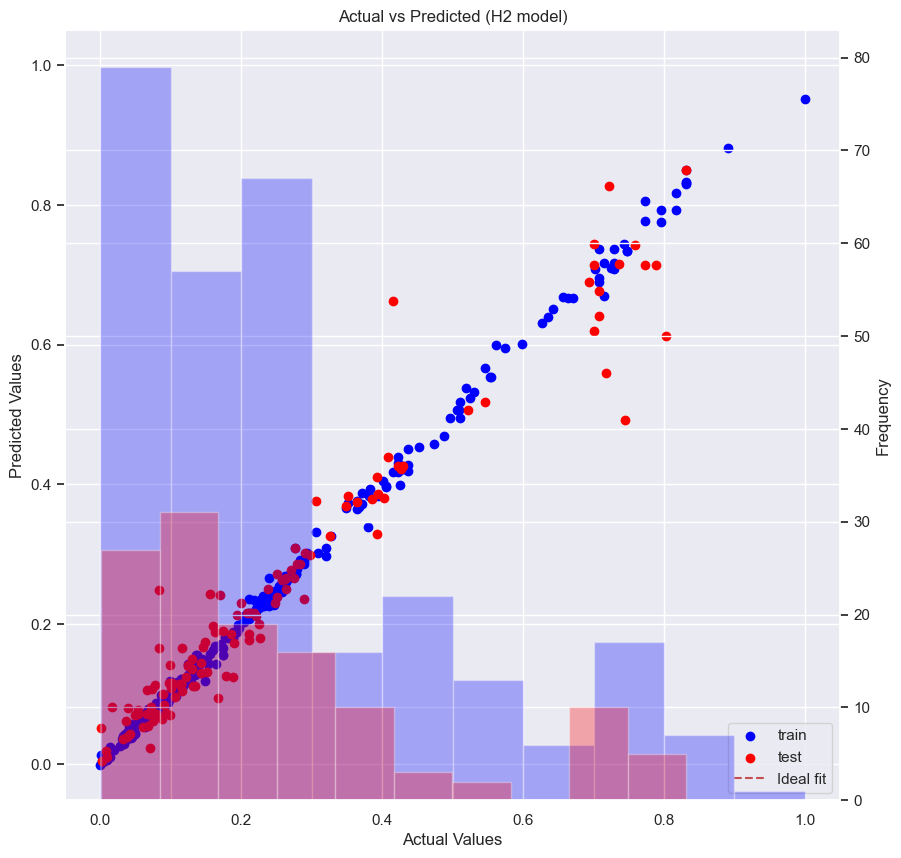

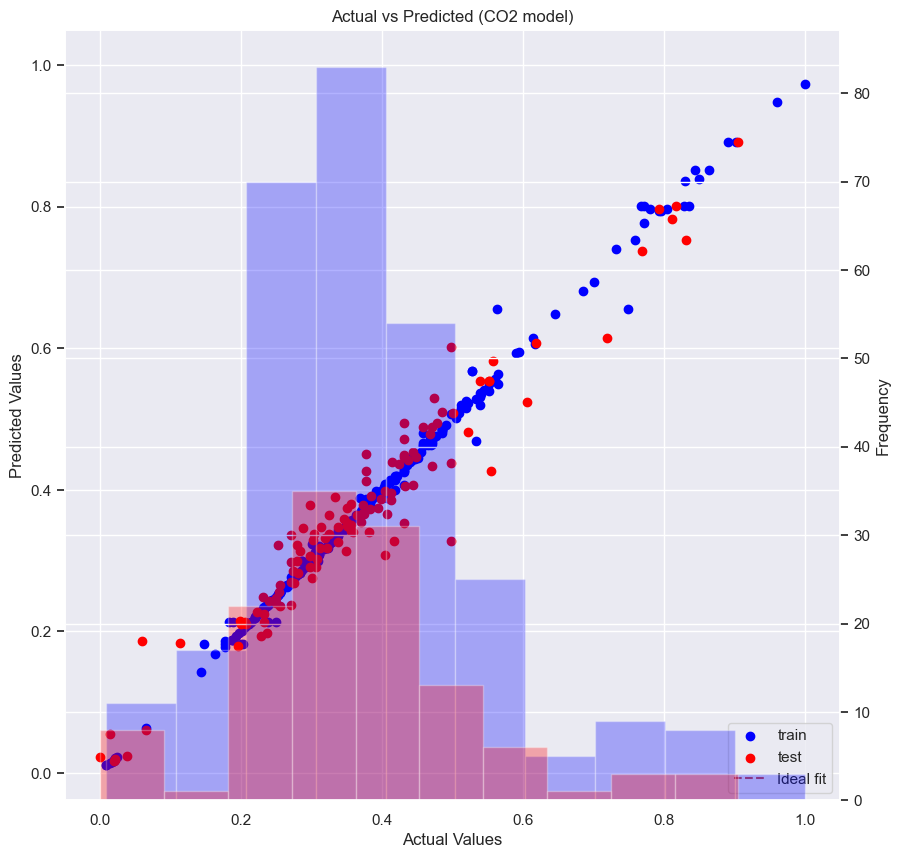

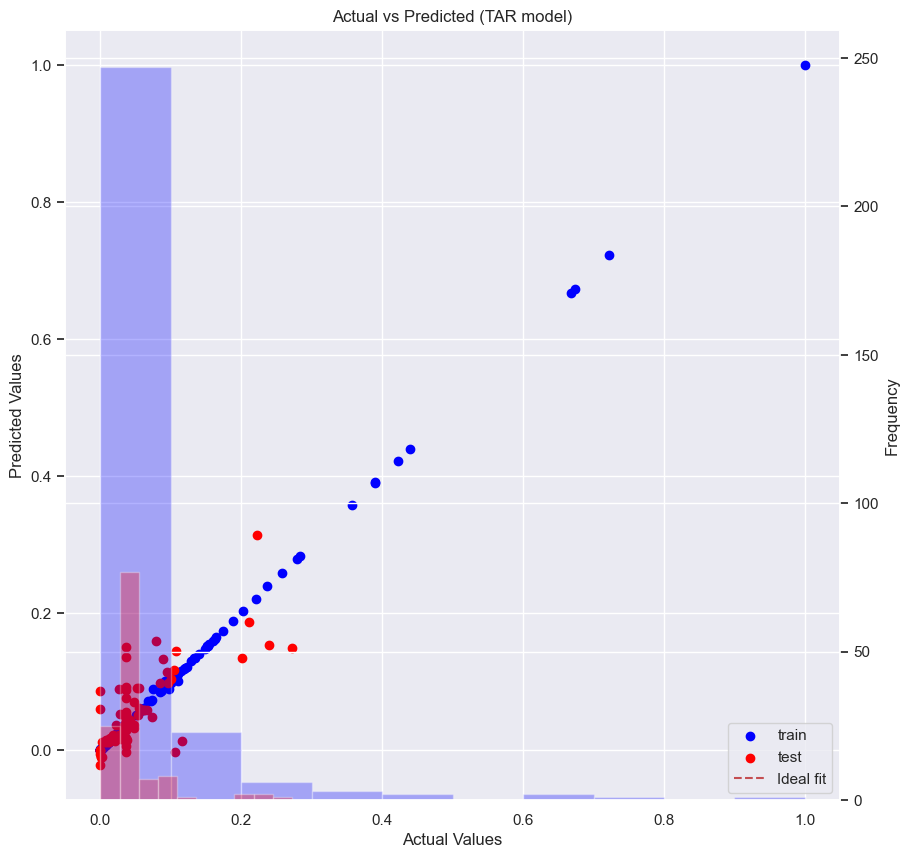

In [18]:
for model in ['H2', 'CO2', 'gas_tar']:
  fig, ax1 = plt.subplots(figsize=(10,10))
  ax1.scatter(Y_train[model], Predict_train[model], color='blue', label='train')
  ax1.scatter(Y_test[model], Predict_test[model], color='red', label='test')
  ax1.plot([0,0], [1,1], 'r--', label='Ideal fit')
  ax1.set_xlabel('Actual Values')
  ax1.set_ylabel('Predicted Values')
  ax1.legend()

  ax2 = ax1.twinx()
  ax2.hist(Y_train[model], bins=10, alpha=0.3, color='blue')
  ax2.hist(Y_test[model], bins=10, alpha=0.3, color='red')
  ax2.set_ylabel('Frequency')
  
  if model == 'gas_tar':
    model = 'TAR'
  plt.title(f'Actual vs Predicted ({model} model)')
  plt.show()

ValueError: If using all scalar values, you must pass an index

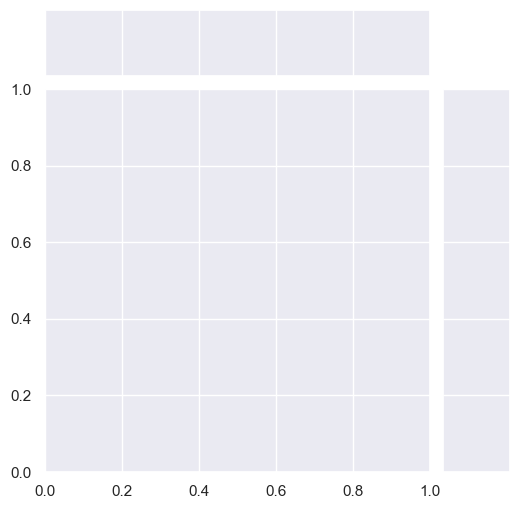

In [19]:
#x_labels = [r'Target $H_{2}$ [vol. % db]',
#            r'Target $CO_{2}$ [vol. % db]',
#            r'Target Tar [g/$Nm^{3}$]',
#            ]
#y_labels = [r'Predicted $H_{2}$ [vol. % db]',
#            r'Predicted $CO_{2}$ [vol. % db]',
#            r'Predicted $CH_{4}$ [vol. % db]',
#            r'Predicted Tar [g/$Nm^{3}$]',
#            ]
#target_axis_string = x_labels[count]
#predicted_axis_string = y_labels[count]
g = sns.JointGrid(x=Y_test, y=Predict_test)
g.fig.set_figwidth(5) # change fig width for publication
g.fig.set_figheight(2.25) # change fig height for publication
sns.scatterplot(x=Y_train, y=Predict_train, s=100, color='orange', ax=g.ax_joint)
sns.scatterplot(x=Y_test, y=Predict_test, s=100, color='blue', ax=g.ax_joint)
# sns.regplot(x=Y_test_pretreated, y=y_test_pred, ax=g.ax_joint)
#g.set_axis_labels(target_axis_string, predicted_axis_string, fontsize =16, fontname = 'Arial')
sns.histplot(x=Y_train,ax=g.ax_marg_x, color ='orange')
sns.histplot(x=Y_test, ax=g.ax_marg_x, color ='blue')
g.ax_marg_x.legend(['Train', 'Test'])
plt.show()